# **Wine quality prediction**
In this notebook, we try to predict the quality of red wine (scored 3-8) using its chemical properties such as alcohol level, acidity, and sulphates. We use Linear Regression and Decision Tree as our main models, and also explore PCA and clustering techniques to better understand the data.

### **Imports and load data**

We import pandas and numpy for data handling, matplotlib and seaborn for visualisations, and sklearn for building machine learning models.
The red wine dataset which contains 1599 wines, each described by 11 chemical features. Our goal is to predict the 'quality' column which is a score given by human tasters between 3 and 8.

We will then split the data into a training set (80%) to teach the model, as well as a test set (20%) to evaluate how well it performs on data it has never seen before. This prevents the model from just memorising the answers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Load data
#red_wine = pd.read_csv("winequality-red.csv", sep=";")
red_wine = pd.read_csv("../data/raw/winequality-red.csv", sep=";")

X = red_wine.drop("quality", axis=1)
y = red_wine["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **Dummy model**

Before building real models, we will create a dummy model that simply predicts the average wine quality every time regardless of the features. This gives us a baseline to beat: any real model should perform better than this, otherwise it isn't learning anything useful from the data.

In [3]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Dummy Model ===")
print(f"MSE:  {mean_squared_error(y_test, y_pred_dummy):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_dummy):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_dummy):.4f}")

=== Dummy Model ===
MSE:  0.6572
R²:   -0.0056
MAE:  0.6853


### **Linear Regression**

Linear Regression tries to find a straight line relationship between the chemical features and wine quality.
We evaluate all models using three metrics:
- MSE (Mean Squared Error): Average squared difference between predicted and actual quality - lower is better
- R² (R-squared): How much of the variation in quality the model explains - higher is better, maximum is 1.0
- MAE (Mean Absolute Error): Average absolute difference between predicted and actual - lower is better

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"MSE:  {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.4f}")

=== Linear Regression ===
MSE:  0.3900
R²:   0.4032
MAE:  0.5035


### **Decision Tree**

Now, we train a decision tree regression model on the training data, uses it to make predictions on the test set, and then evaluates its performance using MSE, R², and MAE metrics. A decision tree is a model that makes predictions by splitting data into branches based on feature values, forming a tree-like structure of decisions. It learns simple rules from the data to predict outcomes for new inputs.

In [5]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print(f"MSE:  {mean_squared_error(y_test, y_pred_dt):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_dt):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_dt):.4f}")

=== Decision Tree ===
MSE:  0.6062
R²:   0.0723
MAE:  0.4625


### **Comparision Table**

Now we create a comparison table using a pandas DataFrame to evaluate three models (Dummy, Linear Regression, and Decision Tree) based on MSE, R², and MAE.

In [6]:
results = pd.DataFrame({
    "Model": ["Dummy", "Linear Regression", "Decision Tree"],
    "MSE": [
        mean_squared_error(y_test, y_pred_dummy),
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_dt)
    ],
    "R²": [
        r2_score(y_test, y_pred_dummy),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_dummy),
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt)
    ]
})
print(results)

               Model       MSE        R²       MAE
0              Dummy  0.657160 -0.005592  0.685284
1  Linear Regression  0.390025  0.403180  0.503530
2      Decision Tree  0.606250  0.072311  0.462500


- Linear Regression performs best overall (lowest MSE ≈ 0.39, highest R² ≈ 0.40, lowest MAE ≈ 0.51), meaning it explains the data reasonably well.
- Decision Tree performs worse (higher MSE ≈ 0.61, low R² ≈ 0.07), suggesting weak predictive power and possible overfitting or poor generalization.
- Dummy model is the worst (negative R²), indicating it performs worse than simply predicting the mean.

### **Visualisation**

Next, we create side-by-side scatter plots comparing actual vs predicted values for the Linear Regression and Decision Tree models, with a reference diagonal line showing perfect predictions.

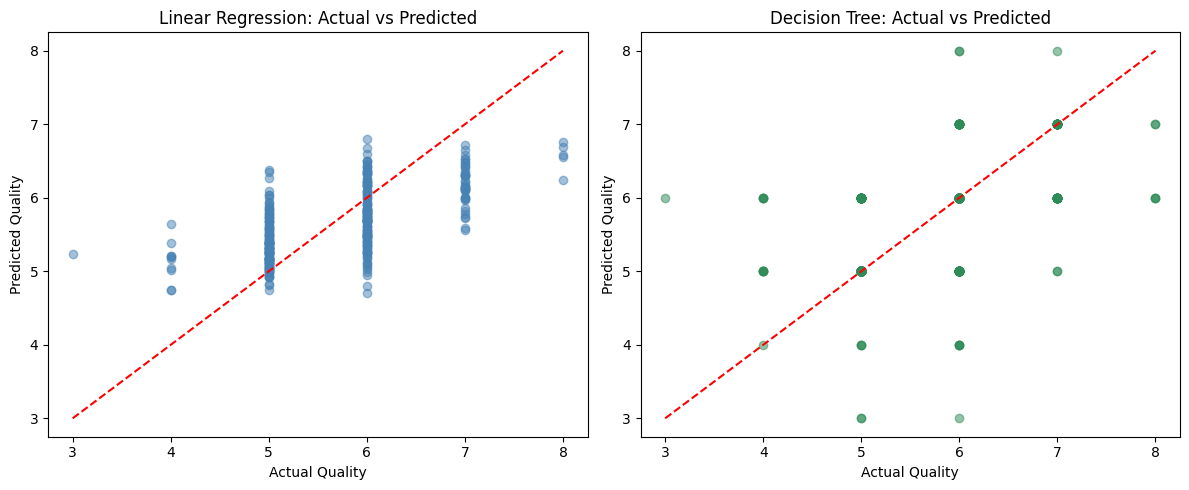

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
axes[0].plot([3, 8], [3, 8], 'r--')
axes[0].set_title("Linear Regression: Actual vs Predicted")
axes[0].set_xlabel("Actual Quality")
axes[0].set_ylabel("Predicted Quality")

axes[1].scatter(y_test, y_pred_dt, alpha=0.5, color='seagreen')
axes[1].plot([3, 8], [3, 8], 'r--')
axes[1].set_title("Decision Tree: Actual vs Predicted")
axes[1].set_xlabel("Actual Quality")
axes[1].set_ylabel("Predicted Quality")

plt.tight_layout()
plt.savefig("plots/model_comparison.png")
plt.show()

- Linear Regression plot: Points are more closely clustered around the diagonal line, indicating better and more consistent predictions.
- Decision Tree plot: Points are more scattered and less aligned with the diagonal, showing higher error and less reliable predictions.
- Overall, the visualization confirms that Linear Regression outperforms the Decision Tree, as its predictions are closer to the true values.

Some features like 'total sulfur dioxide' have much larger values than others like 'citric acid'. 
StandardScaler rescales all features to have mean=0 and the same standard deviation, putting them all on the same scale.
The original Decision Tree is overfitting - it was basically memorising the training data but performing poorly on new data. We fix this by limiting how deep the tree can grow (max_depth=5) and requiring at least 10 samples before making a split (min_samples_split=10). 
This forces the model to learn general patterns rather than memorising noise.

#### **Scaling Regression Model**

To improve model performance, we first standardize the features so that all variables are on the same scale.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Now the training and test data are properly scaled, making them more suitable for models sensitive to feature magnitudes like linear regression.

#### **Improving the Linear regression**

Next, we retrain the Linear Regression model using the scaled data to see if performance improves.

In [9]:
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)
y_pred_lr_scaled = lr_scaled.predict(X_test_scaled)

print("=== Linear Regression (Scaled) ===")
print(f"MSE:  {mean_squared_error(y_test, y_pred_lr_scaled):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_lr_scaled):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr_scaled):.4f}")

=== Linear Regression (Scaled) ===
MSE:  0.3900
R²:   0.4032
MAE:  0.5035


The results show nearly identical performance, confirming that scaling has little effect on basic linear regression in this case.

#### **Tuning the decision tree**

We then tune the Decision Tree by limiting its depth and requiring more samples per split to reduce overfitting.

In [10]:
dt_tuned = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt_tuned.fit(X_train_scaled, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test_scaled)

print("=== Decision Tree (Tuned) ===")
print(f"MSE:  {mean_squared_error(y_test, y_pred_dt_tuned):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_dt_tuned):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_dt_tuned):.4f}")

=== Decision Tree (Tuned) ===
MSE:  0.4336
R²:   0.3365
MAE:  0.4968


The tuned model performs significantly better, with improved R² and lower errors (from 0.072311 to 0.3365), indicating better generalization.

#### **Updating the comparison table**

Finally, we update the comparison table to include all models—original, scaled, and tuned—so we can clearly evaluate their performance side by side.

In [11]:
results = pd.DataFrame({
    "Model": ["Dummy", "Linear Regression", "Linear Regression (Scaled)", 
              "Decision Tree", "Decision Tree (Tuned)"],
    "MSE": [
        mean_squared_error(y_test, y_pred_dummy),
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_lr_scaled),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_dt_tuned)
    ],
    "R²": [
        r2_score(y_test, y_pred_dummy),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_lr_scaled),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_dt_tuned)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_dummy),
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_lr_scaled),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_dt_tuned)
    ]
})
print(results)

                        Model       MSE        R²       MAE
0                       Dummy  0.657160 -0.005592  0.685284
1           Linear Regression  0.390025  0.403180  0.503530
2  Linear Regression (Scaled)  0.390025  0.403180  0.503530
3               Decision Tree  0.606250  0.072311  0.462500
4       Decision Tree (Tuned)  0.433573  0.336542  0.496833


Here we compare all models side by side. Key observations include:
- Linear Regression achieves R²=0.40 whether scaled or not, meaning it explains about 40% of the variation in wine quality
- The original Decision Tree badly overfits with R²=0.07 on the test set
- Tuning the Decision Tree significantly improves it to R²=0.34
- Overall, all models beat the dummy baseline which confirms they are learning something from the data
- The relatively low scores overall suggests that wine quality is a genuinely difficult prediction problem

Having evaluated and compared our models, we now turn to feature reduction techniques to further improve efficiency and uncover underlying patterns in the data—starting with Principal Component Analysis (PCA).

### **Principal Component Analysis**

PCA (Principal Component Analysis) is a technique that reduces the number of features while keeping as much useful information as possible. It does this by finding new directions in the data that capture the most variation.

Results: The cumulative variance plot shows that **7** components are enough to capture **90%** of the information in the data, meaning 4 of our 11 original features are largely redundant.

The 2D projection shows that wine quality classes overlap heavily with no clear separation between good and bad wines. This explains why our models struggle - wines with very different quality scores can have very similar chemical properties, making the quality hard to predict from these features alone.

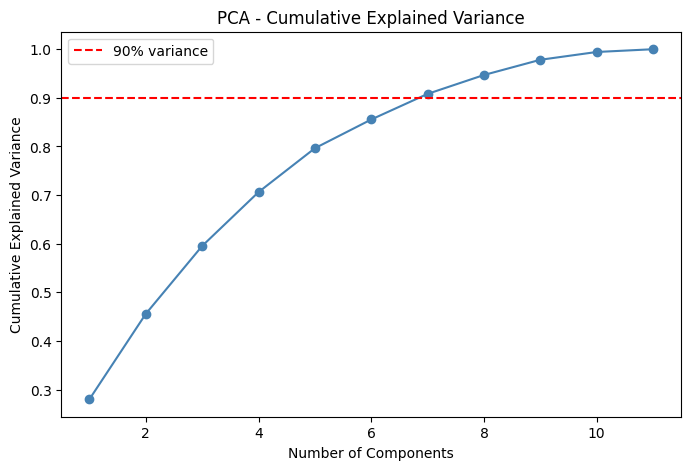

In [12]:
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), marker='o', color='steelblue')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.title("PCA - Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.savefig("plots/pca.png")
plt.show()

#### **Visualisation of PCS (2D Analysis)**

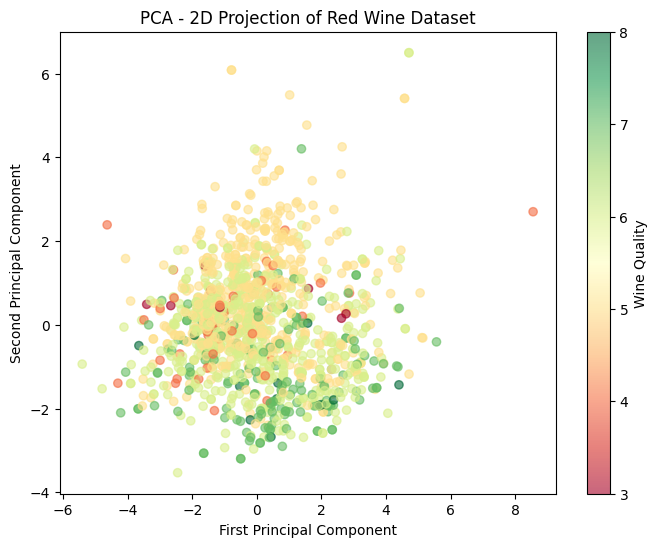

In [13]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='RdYlGn', alpha=0.6)
plt.colorbar(scatter, label='Wine Quality')
plt.title("PCA - 2D Projection of Red Wine Dataset")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.savefig("plots/pca_2d.png")
plt.show()

While PCA helps us visualize the data and uncover its underlying structure, it does not explicitly group similar observations. To go a step further, we apply clustering techniques to automatically identify natural groupings of wines based on their features, which can reveal hidden patterns and similarities in quality profiles.

## **Cluster Analsyis**

### **K - Means: Finding optimal K**

K-Means is an unsupervised learning technique: It finds patterns in the data without being told the quality labels. It groups wines into K clusters based on their chemical similarity.

We will use two methods to find the optimal number of clusters:
- Elbow Method: we look for the point where adding more clusters stops significantly reducing inertia (the within-cluster variance)
- Silhouette Score: measures how well separated the clusters are (higher is better)
  
We then compare the resulting clusters to actual quality scores to see whether chemically similar wines also tend to taste similar.

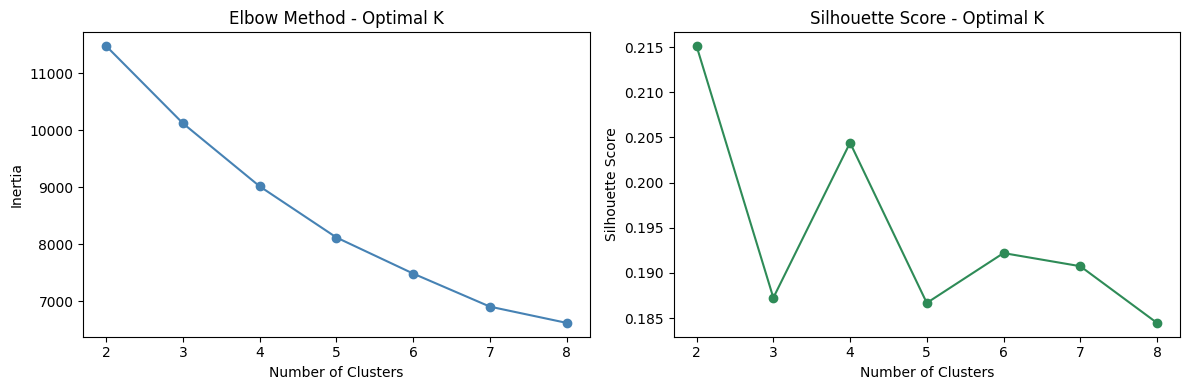

In [14]:
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertia, marker='o', color='steelblue')
axes[0].set_title("Elbow Method - Optimal K")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, silhouette_scores, marker='o', color='seagreen')
axes[1].set_title("Silhouette Score - Optimal K")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("plots/kmeans_elbow.png")
plt.show()

We chose K = 3 because the elbow plot shows a clear reduction in within-cluster variance up to K=4. Additionally, the silhouette score at K = 3 remains reasonably high, suggesting a good balance between cluster cohesion and separation

#### **Visualisation of K-Means**

In this step, we apply K-Means clustering to group the wines into 4 clusters based on their scaled features. We then visualize these clusters using PCA in 2D and analyze how the actual wine quality is distributed within each cluster using boxplots and summary statistics, helping us understand how well the clusters relate to quality differences.

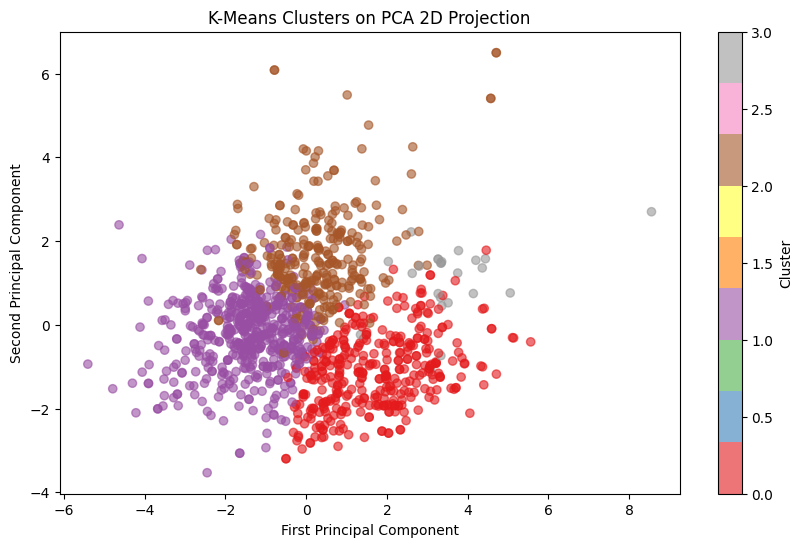

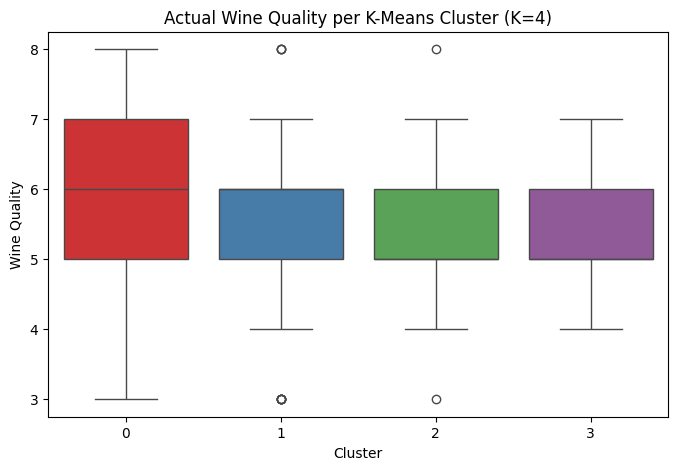

         count      mean       std  min  25%  50%  75%  max
cluster                                                    
0        376.0  6.002660  0.850094  3.0  5.0  6.0  7.0  8.0
1        574.0  5.547038  0.786258  3.0  5.0  6.0  6.0  8.0
2        305.0  5.324590  0.603895  3.0  5.0  5.0  6.0  8.0
3         24.0  5.333333  0.637022  4.0  5.0  5.0  6.0  7.0


In [21]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_km = km_final.fit_predict(X_train_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=clusters_km, cmap='Set1', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title("K-Means Clusters on PCA 2D Projection")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.savefig("plots/kmeans_pca.png")
plt.show()

cluster_df = pd.DataFrame({
    'cluster': clusters_km,
    'actual_quality': y_train.values
})

plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y='actual_quality', data=cluster_df, 
            hue='cluster', palette='Set1', legend=False)
plt.title("Actual Wine Quality per K-Means Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Wine Quality")
plt.savefig("plots/kmeans_quality.png")
plt.show()

print(cluster_df.groupby('cluster')['actual_quality'].describe())

K-means with K=4 reveals partially separated groups in PCA space, though noticeable overlap indicates limited cluster distinctiveness. Cluster 0 stands out with the highest mean quality (6.00) and wider spread, suggesting more variability. Clusters 1, 2, and 3 have lower means (~5.3–5.5) and tighter distributions. Cluster 3 is very small (24 points), indicating maybe a niche subgroup.

### **Heirarchial Clustering: Dendogram**

Hierarchical Clustering is another unsupervised method that builds a tree of clusters called a dendrogram. It works by progressively merging the most similar wines together until everything is in one group.

Unlike K-Means, it does not require us to choose the number of clusters upfront - hence, we can read the best number from the dendrogram by looking at where the biggest jumps in distance occur.

We will use Ward's method which minimises the variance within each cluster, making it comparable to K-Means.

Since K-means suggested using 4 clusters, we visualize the dendrogram with 4 clusters to see if hierarchical clustering supports this structure.

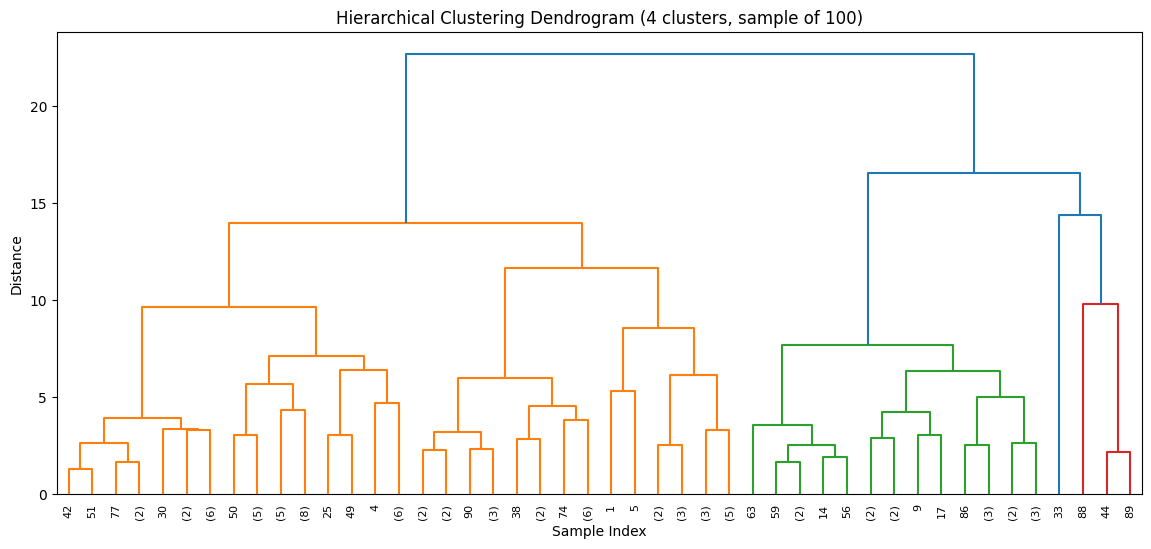

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

sample = X_train_scaled[:100]
linked = linkage(sample, method='ward')

# threshold to get 4 clusters
threshold = linked[-(4 - 1), 2]

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='level',
    p=5,
    color_threshold=threshold,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram (4 clusters, sample of 100)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.savefig("plots/dendrogram.png")
plt.show()

However, the 4-cluster cut does not look very convincing, as some clusters are not well separated and appear unbalanced (one cluster is very small while others are merged). Therefore, we re-plot the dendrogram and choose 3 clusters by cutting the tree at a more appropriate height h (using a horizontal line).

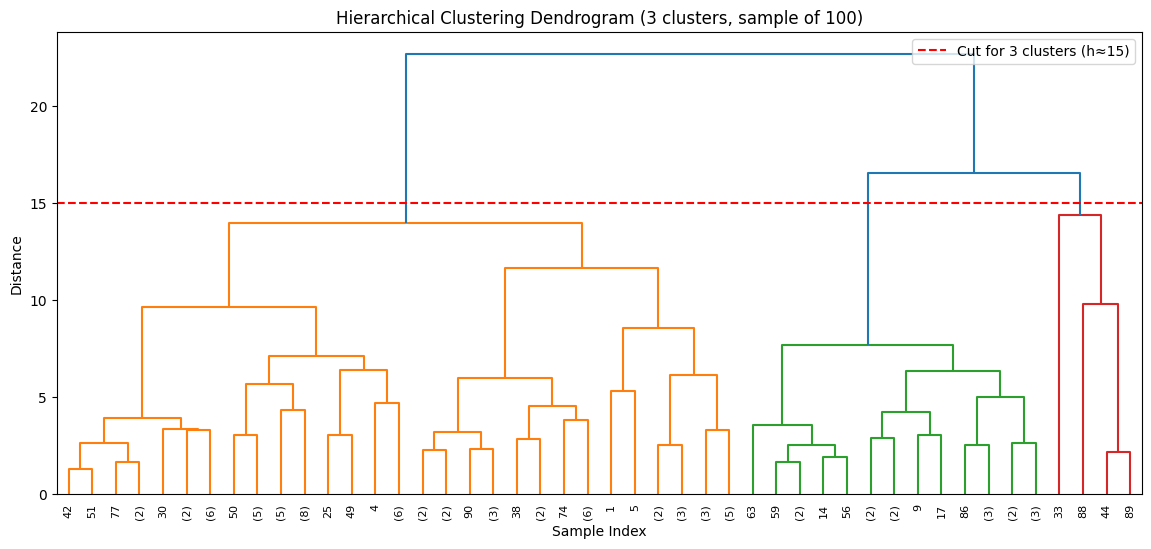

In [25]:
plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=8
)

# horizontal line to cut into 3 clusters
plt.axhline(y=15, color='red', linestyle='--', label='Cut for 3 clusters (h≈15)')

plt.title("Hierarchical Clustering Dendrogram (3 clusters, sample of 100)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.legend()
plt.savefig("plots/dendrogram_3_clusters.png")
plt.show()

#### **Visualisation of Heirarchial Clustering**

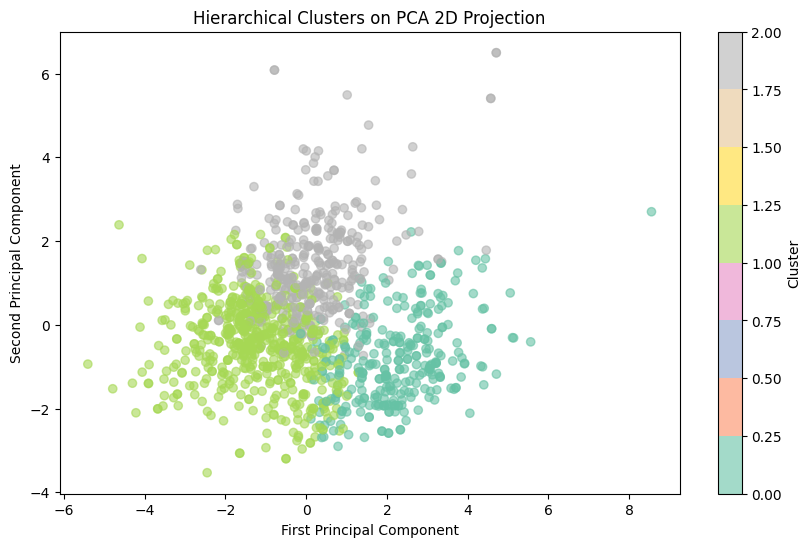

/tmp/ipykernel_359/454623600.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='actual_quality', data=hc_df, palette='Set2')


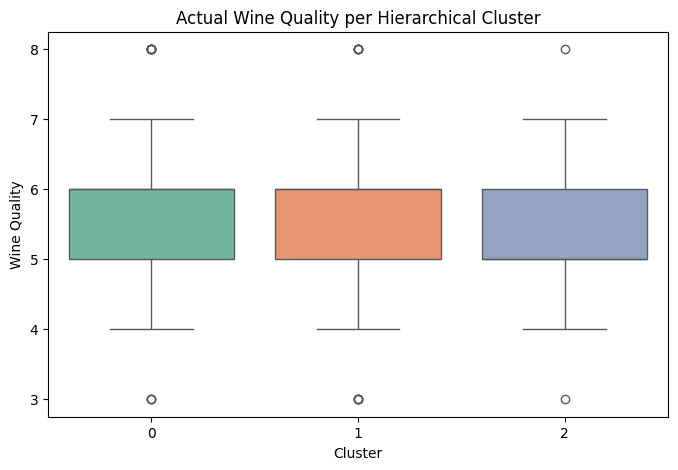

         count      mean       std  min  25%  50%  75%  max
cluster                                                    
0        307.0  5.879479  0.856617  3.0  5.0  6.0  6.0  8.0
1        616.0  5.642857  0.821884  3.0  5.0  6.0  6.0  8.0
2        356.0  5.370787  0.647979  3.0  5.0  5.0  6.0  8.0


In [26]:
hc = AgglomerativeClustering(n_clusters=3)
clusters_hc = hc.fit_predict(X_train_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=clusters_hc, cmap='Set2', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title("Hierarchical Clusters on PCA 2D Projection")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.savefig("plots/hc_pca.png")
plt.show()

hc_df = pd.DataFrame({
    'cluster': clusters_hc,
    'actual_quality': y_train.values
})

plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y='actual_quality', data=hc_df, palette='Set2')
plt.title("Actual Wine Quality per Hierarchical Cluster")
plt.xlabel("Cluster")
plt.ylabel("Wine Quality")
plt.savefig("plots/hc_quality.png")
plt.show()

print(hc_df.groupby('cluster')['actual_quality'].describe())

The hierarchical clustering results show three clusters with very similar distributions of wine quality. The mean quality values are close (around 5.37–5.88), and the boxplots heavily overlap, indicating that the clusters are not strongly differentiated by quality. This suggests that, like K-Means, hierarchical clustering captures some structure in the data but does not clearly separate wines based on their quality levels.

### **Comparision of K-Means and Heirarchial methods**

In [27]:
print("K-Means Silhouette Score:")
print(f"{silhouette_score(X_train_scaled, clusters_km):.4f}")

print("\n Hierarchical Silhouette Score:")
print(f"{silhouette_score(X_train_scaled, clusters_hc):.4f}")

K-Means Silhouette Score:
0.2044

 Hierarchical Silhouette Score:
0.1594


Both scores are quite low, which is consistent with what we saw in the PCA 2D plot - the wine quality classes are heavily overlapping and not naturally well separated into distinct clusters. K-Means performs slightly better than Hierarchical Clustering on this dataset.

Overall conclusion: wine quality is a complex prediction problem. The chemical features alone do not cleanly separate wines into quality groups, which limits how well both our regression models and clustering methods can perform. More advanced models like Random Forest are likely to handle this complexity better.